# 02 Preprocess and Split


In [1]:
from __future__ import annotations

import html
import importlib.util
import json
import math
import os
import re
import time
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

CODE_DIR = Path('/Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection')
PROJECT_ROOT = Path('/Users/tiencains/Documents/dissertation/dissertation process')
DATA_DIR = PROJECT_ROOT / 'data choosing list' / 'Phishing Email Curated Datasets'
CEAS_PATH = DATA_DIR / 'CEAS_08.csv'
ENRON_PATH = DATA_DIR / 'Enron.csv'
API_KEY_FILE = CODE_DIR / 'openai_api_key.txt'

OUTPUT_DIR = CODE_DIR / 'output'
DATA_OUTPUT_DIR = OUTPUT_DIR / 'data'
STATS_OUTPUT_DIR = OUTPUT_DIR / 'statistics'
FIGURE_OUTPUT_DIR = OUTPUT_DIR / 'figures'
MODEL_OUTPUT_DIR = OUTPUT_DIR / 'models'
EMBEDDING_OUTPUT_DIR = OUTPUT_DIR / 'embeddings'
ERROR_OUTPUT_DIR = OUTPUT_DIR / 'error_analysis'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'reports'

RANDOM_SEED = 42
EXPECTED_RAW_ROWS = 68921
EXPECTED_RAW_LABEL_COUNTS = {1: 35818, 0: 33103}
SCALABILITY_EMAIL_COUNTS = [10_000, 100_000, 1_000_000]

# I keep pricing assumptions here so I can update the cost section before final writing.
EMBEDDING_PRICES_USD_PER_1M_TOKENS = {
    'text-embedding-3-small': 0.02,
    'text-embedding-3-large': 0.13,
}

API_KEY_EMPTY_MARKERS = {
    '',
    'PENGFEI_OPENAI_KEY_FOR_EMBEDDINGS',
}

os.chdir(CODE_DIR)
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_DIR / 'matplotlib_cache'))


def ensure_output_dirs() -> None:
    for path in [
        OUTPUT_DIR,
        DATA_OUTPUT_DIR,
        STATS_OUTPUT_DIR,
        FIGURE_OUTPUT_DIR,
        MODEL_OUTPUT_DIR,
        EMBEDDING_OUTPUT_DIR,
        ERROR_OUTPUT_DIR,
        REPORT_OUTPUT_DIR,
    ]:
        path.mkdir(parents=True, exist_ok=True)


def check_packages(packages: Iterable[str]) -> list[str]:
    return [package for package in packages if importlib.util.find_spec(package) is None]


def require_packages(packages: Iterable[str]) -> None:
    missing = check_packages(packages)
    if missing:
        raise RuntimeError(
            'Missing packages: ' + ', '.join(missing) +
            '. In PyCharm, select the project .venv interpreter, or install these packages in that interpreter.'
        )


def now_seconds() -> float:
    return time.perf_counter()


def elapsed(start: float) -> float:
    return round(time.perf_counter() - start, 4)


def save_json(data: dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding='utf-8')


def load_openai_api_key() -> str | None:
    env_key = os.getenv('OPENAI_API_KEY', '').strip()
    if env_key and env_key not in API_KEY_EMPTY_MARKERS:
        return env_key
    if not API_KEY_FILE.exists():
        return None
    for raw_line in API_KEY_FILE.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('OPENAI_API_KEY='):
            line = line.split('=', 1)[1].strip()
        line = line.strip().strip('"').strip("'")
        if line and line not in API_KEY_EMPTY_MARKERS:
            os.environ['OPENAI_API_KEY'] = line
            return line
    return None


def standardize_email_frame(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    df = df.copy()
    df['source_dataset'] = source_name
    for col in ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']:
        if col not in df.columns:
            df[col] = pd.NA
    df['subject'] = df['subject'].fillna('').astype(str)
    df['body'] = df['body'].fillna('').astype(str)
    df['text'] = (
        df['subject'].str.cat(df['body'], sep=' ')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
    return df[['source_dataset', 'sender', 'receiver', 'date', 'subject', 'body', 'text', 'label', 'urls']]


URL_RE = re.compile(r'(https?://\S+|www\.\S+)', flags=re.IGNORECASE)
EMAIL_RE = re.compile(r'\b[\w.\-+%]+@[\w.\-]+\.[A-Za-z]{2,}\b')
HTML_TAG_RE = re.compile(r'<[^>]+>')
CONTROL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')
NUMBER_RE = re.compile(r'\b\d+(?:[.,:/-]\d+)*\b')
MULTISPACE_RE = re.compile(r'\s+')


def strip_html(text: str) -> str:
    text = html.unescape(str(text))
    return HTML_TAG_RE.sub(' ', text)


def clean_text_level1(text: str) -> str:
    text = strip_html(text)
    text = CONTROL_RE.sub(' ', text)
    text = URL_RE.sub(' URLTOKEN ', text)
    text = EMAIL_RE.sub(' EMAILTOKEN ', text)
    text = NUMBER_RE.sub(' NUMBERTOKEN ', text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9_<>@\s\-']", ' ', text)
    return MULTISPACE_RE.sub(' ', text).strip()


def make_dedup_key(text: pd.Series) -> pd.Series:
    return (
        text.fillna('').astype(str).map(strip_html).str.lower()
        .str.replace(r'\s+', ' ', regex=True).str.strip()
    )


def simple_tokenize(text: str) -> list[str]:
    return re.findall(r"[a-z0-9_<>@\-']+", str(text).lower())


OBFUSCATION_MAP = {
    'password': 'p a s s w 0 r d',
    'account': 'acc0unt',
    'verify': 'ver!fy',
    'login': 'log-in',
    'click': 'cl1ck',
    'urgent': 'urg3nt',
    'security': 'sec urity',
    'bank': 'b@nk',
    'payment': 'pay ment',
    'update': 'up date',
}


def perturb_text_level2(text: str) -> str:
    text = strip_html(text)
    text = URL_RE.sub(' hxxps://example[.]com/secure-login ', text)
    text = EMAIL_RE.sub(' support [at] example [dot] com ', text)
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, OBFUSCATION_MAP)) + r')\b', re.I)

    def replace_word(match: re.Match[str]) -> str:
        word = match.group(0)
        replacement = OBFUSCATION_MAP.get(word.lower(), word)
        return replacement.upper() if word.isupper() else replacement

    text = pattern.sub(replace_word, text)
    text = re.sub(r'([!?.,;:])', r' \1 ', text)
    return re.sub(r'\s+', ' ', text).strip()


def add_text_length_columns(df: pd.DataFrame, column: str = 'text') -> pd.DataFrame:
    df = df.copy()
    df['char_count'] = df[column].fillna('').astype(str).str.len()
    df['word_count'] = df[column].fillna('').astype(str).str.split().str.len()
    return df


def validate_raw_counts(df: pd.DataFrame) -> None:
    actual_rows = len(df)
    actual_counts = {int(k): int(v) for k, v in df['label'].value_counts(dropna=False).to_dict().items() if pd.notna(k)}
    if actual_rows != EXPECTED_RAW_ROWS:
        raise AssertionError(f'Unexpected raw row count: {actual_rows}; expected {EXPECTED_RAW_ROWS}')
    if actual_counts != EXPECTED_RAW_LABEL_COUNTS:
        raise AssertionError(f'Unexpected raw label counts: {actual_counts}; expected {EXPECTED_RAW_LABEL_COUNTS}')


def estimate_tokens_from_text(text: str) -> int:
    # I use this lightweight estimate so the cost comparison stays reproducible offline.
    text = str(text)
    return max(1, math.ceil(len(text) / 4))


def estimate_tokens_for_series(texts: pd.Series) -> int:
    return int(texts.fillna('').astype(str).map(estimate_tokens_from_text).sum())


def estimate_embedding_cost_usd(model_name: str, total_tokens: int) -> float:
    price = EMBEDDING_PRICES_USD_PER_1M_TOKENS.get(model_name, 0.0)
    return round((total_tokens / 1_000_000) * price, 6)


def projected_seconds(seconds_per_email: float, email_count: int) -> float:
    return round(seconds_per_email * email_count, 4)


def projected_cost(cost_per_email: float, email_count: int) -> float:
    return round(cost_per_email * email_count, 6)


def add_cost_columns(row: dict[str, Any], row_count: int, token_cost_usd: float = 0.0, total_tokens: int = 0) -> dict[str, Any]:
    inference_seconds = float(row.get('inference_seconds', 0.0) or 0.0)
    feature_seconds = float(row.get('feature_generation_seconds', row.get('embedding_seconds', row.get('vectorizer_seconds', 0.0))) or 0.0)
    train_seconds = float(row.get('train_seconds', 0.0) or 0.0)
    total_runtime = feature_seconds + train_seconds + inference_seconds
    seconds_per_email = inference_seconds / row_count if row_count else 0.0
    cost_per_email = token_cost_usd / row_count if row_count else 0.0
    row.update({
        'total_runtime_seconds': round(total_runtime, 4),
        'inference_seconds_per_email': round(seconds_per_email, 8),
        'throughput_emails_per_second': round(row_count / inference_seconds, 4) if inference_seconds > 0 else np.nan,
        'estimated_input_tokens': int(total_tokens),
        'estimated_token_cost_usd': round(token_cost_usd, 6),
        'estimated_cost_per_email_usd': round(cost_per_email, 10),
        'projected_seconds_10k': projected_seconds(seconds_per_email, 10_000),
        'projected_seconds_100k': projected_seconds(seconds_per_email, 100_000),
        'projected_seconds_1m': projected_seconds(seconds_per_email, 1_000_000),
        'projected_cost_10k_usd': projected_cost(cost_per_email, 10_000),
        'projected_cost_100k_usd': projected_cost(cost_per_email, 100_000),
        'projected_cost_1m_usd': projected_cost(cost_per_email, 1_000_000),
    })
    return row


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, scores: np.ndarray | None) -> dict[str, Any]:
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'false_positive_rate': fp / (fp + tn) if (fp + tn) else 0.0,
        'false_negative_rate': fn / (fn + tp) if (fn + tp) else 0.0,
    }
    if scores is not None and len(np.unique(y_true)) == 2:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, scores)
        except ValueError:
            metrics['roc_auc'] = np.nan
    else:
        metrics['roc_auc'] = np.nan
    return metrics


def model_scores(model: Any, x: Any) -> np.ndarray | None:
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(x)
        if proba.ndim == 2 and proba.shape[1] > 1:
            return proba[:, 1]
    if hasattr(model, 'decision_function'):
        return np.asarray(model.decision_function(x))
    return None


def evaluate_model(model: Any, x: Any, y: np.ndarray) -> tuple[dict[str, Any], np.ndarray, np.ndarray | None]:
    start = now_seconds()
    y_pred = model.predict(x)
    inference_seconds = elapsed(start)
    scores = model_scores(model, x)
    metrics = classification_metrics(y, y_pred, scores)
    metrics['inference_seconds'] = inference_seconds
    return metrics, np.asarray(y_pred), scores


def export_error_cases(df: pd.DataFrame, y_pred: np.ndarray, scores: np.ndarray | None, model_id: str) -> tuple[Path, Path]:
    ERROR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    errors = df.copy()
    errors['predicted_label'] = y_pred
    errors['prediction_score'] = scores if scores is not None else np.nan
    cols = [c for c in ['source_dataset', 'subject', 'text', 'text_clean', 'label', 'predicted_label', 'prediction_score'] if c in errors.columns]
    false_negatives = errors[(errors['label'] == 1) & (errors['predicted_label'] == 0)]
    false_positives = errors[(errors['label'] == 0) & (errors['predicted_label'] == 1)]
    fn_path = ERROR_OUTPUT_DIR / f'{model_id}_false_negatives.csv'
    fp_path = ERROR_OUTPUT_DIR / f'{model_id}_false_positives.csv'
    false_negatives[cols].to_csv(fn_path, index=False)
    false_positives[cols].to_csv(fp_path, index=False)
    return fn_path, fp_path


ACADEMIC_BLUE = '#0072B2'
ACADEMIC_VERMILLION = '#D55E00'
ACADEMIC_GREEN = '#009E73'
ACADEMIC_PURPLE = '#CC79A7'
ACADEMIC_ORANGE = '#E69F00'
ACADEMIC_SKY_BLUE = '#56B4E9'
ACADEMIC_YELLOW = '#F0E442'
ACADEMIC_BLACK = '#222222'
ACADEMIC_GRAY = '#666666'
ACADEMIC_LIGHT_GRAY = '#D9D9D9'
ACADEMIC_PALETTE = [
    ACADEMIC_BLUE,
    ACADEMIC_VERMILLION,
    ACADEMIC_GREEN,
    ACADEMIC_PURPLE,
    ACADEMIC_ORANGE,
    ACADEMIC_SKY_BLUE,
    ACADEMIC_YELLOW,
    ACADEMIC_BLACK,
]
CLASS_COLORS = {0: ACADEMIC_BLUE, 1: ACADEMIC_VERMILLION}


def setup_academic_plotting() -> Any:
    import matplotlib
    matplotlib.use('Agg')
    from cycler import cycler
    from matplotlib import pyplot as plt

    plt.rcParams.update({
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'legend.fontsize': 8.5,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': ACADEMIC_BLACK,
        'axes.labelcolor': ACADEMIC_BLACK,
        'xtick.color': ACADEMIC_BLACK,
        'ytick.color': ACADEMIC_BLACK,
        'legend.frameon': False,
        'lines.linewidth': 1.8,
        'patch.edgecolor': 'white',
    })
    plt.rcParams['axes.prop_cycle'] = cycler(color=ACADEMIC_PALETTE)
    return plt


def style_academic_axis(ax: Any) -> None:
    ax.grid(False)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=0.8)
    for spine_name in ['left', 'bottom']:
        ax.spines[spine_name].set_color(ACADEMIC_BLACK)
        ax.spines[spine_name].set_linewidth(0.8)
    if 'top' in ax.spines:
        ax.spines['top'].set_visible(False)
    if 'right' in ax.spines:
        ax.spines['right'].set_visible(False)


def rotate_category_labels(ax: Any, rotation: int = 45) -> None:
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
        label.set_rotation_mode('anchor')


def make_transparent_legend(ax: Any, *args: Any, **kwargs: Any) -> Any:
    kwargs.setdefault('frameon', True)
    kwargs.setdefault('facecolor', 'white')
    kwargs.setdefault('edgecolor', ACADEMIC_LIGHT_GRAY)
    kwargs.setdefault('framealpha', 0.68)
    legend = ax.legend(*args, **kwargs)
    if legend is not None:
        legend.get_frame().set_linewidth(0.8)
    return legend


def save_academic_figure(fig: Any, path_stem: Path) -> None:
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    # I only save PNG files because these are easier to inspect directly in PyCharm.
    fig.savefig(path_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')


def save_confusion_matrix_figure(metrics: dict[str, Any], title: str, path_stem: Path) -> None:
    plt = setup_academic_plotting()
    matrix = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]])
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    image = ax.imshow(matrix, cmap='Blues', interpolation='nearest', aspect='equal')

    ax.set_xticks([0, 1], labels=['Predicted legitimate', 'Predicted phishing'])
    ax.set_yticks([0, 1], labels=['Actual legitimate', 'Actual phishing'])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_title(title)

    ax.grid(False, which='both', axis='both')
    ax.minorticks_off()
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)

    threshold = matrix.max() / 2 if matrix.size else 0
    for i in range(2):
        for j in range(2):
            text_color = 'white' if matrix[i, j] > threshold else 'black'
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color=text_color)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(ACADEMIC_BLACK)
        spine.set_linewidth(0.8)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.ax.grid(False, which='both')
    colorbar.ax.minorticks_off()

    save_academic_figure(fig, path_stem)
    plt.close(fig)


def artifact_size(path: Path) -> int:
    return int(path.stat().st_size) if path.exists() else 0


ensure_output_dirs()
print('Notebook configuration loaded.')
print('Code directory:', CODE_DIR)
print('Output directory:', OUTPUT_DIR)


Notebook configuration loaded.
Code directory: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection
Output directory: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output


In [2]:
def stratified_split(df: pd.DataFrame, label_col: str, test_size: float, random_seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=random_seed)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_balanced_training_set(train_df: pd.DataFrame, random_seed: int) -> pd.DataFrame:
    counts = train_df['label'].value_counts()
    min_count = int(counts.min())
    parts = [train_df[train_df['label'] == label].sample(n=min_count, random_state=random_seed) for label in sorted(counts.index)]
    return pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=random_seed).reset_index(drop=True)


def run_preprocess_and_split() -> dict[str, pd.DataFrame]:
    ensure_output_dirs()
    require_packages(['sklearn', 'matplotlib'])
    plt = setup_academic_plotting()

    input_path = DATA_OUTPUT_DIR / 'merged_ceas_enron_raw.csv'
    if not input_path.exists():
        raise FileNotFoundError('Run the merge and describe notebook before preprocessing.')

    df = pd.read_csv(input_path, low_memory=False)
    df['label'] = pd.to_numeric(df['label'], errors='coerce').astype(int)
    df['text'] = df['text'].fillna('').astype(str)
    df['text_clean'] = df['text'].map(clean_text_level1)
    df['dedup_key'] = make_dedup_key(df['text'])

    before_empty = len(df)
    df = df[df['text_clean'].str.len() > 0].copy()
    empty_removed = before_empty - len(df)

    conflict_counts = df.groupby('dedup_key')['label'].nunique()
    conflicting_texts = conflict_counts[conflict_counts > 1].index
    conflicting_rows = df[df['dedup_key'].isin(conflicting_texts)].copy()
    conflicting_rows.to_csv(DATA_OUTPUT_DIR / 'conflicting_duplicate_texts.csv', index=False)
    df = df[~df['dedup_key'].isin(conflicting_texts)].copy()

    before_dedup = len(df)
    df = df.drop_duplicates(subset=['dedup_key'], keep='first').reset_index(drop=True)
    duplicate_removed = before_dedup - len(df)
    df = df.drop(columns=['dedup_key'])

    processed_path = DATA_OUTPUT_DIR / 'processed_deduplicated.csv'
    df.to_csv(processed_path, index=False)

    train_val, test_df = stratified_split(df, 'label', test_size=.20, random_seed=RANDOM_SEED)
    train_df, validation_df = stratified_split(train_val, 'label', test_size=.25, random_seed=RANDOM_SEED)
    train_balanced_df = make_balanced_training_set(train_df, RANDOM_SEED)

    train_df.to_csv(DATA_OUTPUT_DIR / 'train_unbalanced.csv', index=False)
    train_balanced_df.to_csv(DATA_OUTPUT_DIR / 'train_balanced.csv', index=False)
    validation_df.to_csv(DATA_OUTPUT_DIR / 'validation.csv', index=False)
    test_df.to_csv(DATA_OUTPUT_DIR / 'test_imbalanced.csv', index=False)

    split_rows = []
    for name, split_df in [('processed_deduplicated', df), ('train_unbalanced', train_df), ('train_balanced', train_balanced_df), ('validation', validation_df), ('test_imbalanced', test_df)]:
        counts = split_df['label'].value_counts().to_dict()
        split_rows.append({
            'split': name,
            'rows': len(split_df),
            'label_0_legitimate': int(counts.get(0, 0)),
            'label_1_phishing_spam': int(counts.get(1, 0)),
            'label_1_rate': float((split_df['label'] == 1).mean()),
        })
    split_summary = pd.DataFrame(split_rows)
    split_summary.to_csv(DATA_OUTPUT_DIR / 'split_summary.csv', index=False)

    quality = pd.DataFrame([{
        'empty_text_rows_removed': int(empty_removed),
        'conflicting_duplicate_rows_removed': int(len(conflicting_rows)),
        'deduplicate_rows_removed': int(duplicate_removed),
        'final_processed_rows': int(len(df)),
        'train_balanced_label_counts_equal': bool(train_balanced_df['label'].value_counts().nunique() == 1),
        'test_label_1_rate': float((test_df['label'] == 1).mean()),
    }])
    quality.to_csv(DATA_OUTPUT_DIR / 'preprocessing_quality_checks.csv', index=False)

    if train_balanced_df['label'].value_counts().nunique() != 1:
        raise AssertionError('Balanced training set does not have equal label counts.')
    if int((df['text_clean'].str.len() == 0).sum()) != 0:
        raise AssertionError('Empty cleaned texts remain after preprocessing.')

    fig, ax = plt.subplots(figsize=(7.2, 4.5))
    split_plot = split_summary.set_index('split')[['label_0_legitimate', 'label_1_phishing_spam']]
    split_plot.plot(kind='bar', stacked=True, ax=ax, color=[ACADEMIC_BLUE, ACADEMIC_VERMILLION])
    ax.set_title('Class Counts Across Data Splits')
    ax.set_xlabel('Data split')
    ax.set_ylabel('Email count')
    make_transparent_legend(ax, ['Legitimate (0)', 'Phishing/spam (1)'], loc='upper right')
    rotate_category_labels(ax)
    save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'split_class_counts')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    removal = pd.Series({'Empty text': empty_removed, 'Conflicting duplicates': len(conflicting_rows), 'Duplicate texts': duplicate_removed})
    ax.bar(removal.index, removal.values, color=ACADEMIC_VERMILLION)
    ax.set_title('Rows Removed During Preprocessing')
    ax.set_ylabel('Rows removed')
    rotate_category_labels(ax)
    save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'preprocessing_rows_removed')
    plt.close(fig)

    print(f'Processed data saved to {processed_path}')
    display(split_summary)
    return {'train_balanced': train_balanced_df, 'validation': validation_df, 'test_imbalanced': test_df}


In [3]:
splits = run_preprocess_and_split()


Processed data saved to /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/data/processed_deduplicated.csv


,split,rows,label_0_legitimate,label_1_phishing_spam,label_1_rate
0,processed_deduplicated,68385,32763,35622,0.520904
1,train_unbalanced,41031,19657,21374,0.520923
2,train_balanced,39314,19657,19657,0.500000
3,validation,13677,6553,7124,0.520874
4,test_imbalanced,13677,6553,7124,0.520874


## Preview generated split tables and PNG figures


CSV preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/data/split_summary.csv


,split,rows,label_0_legitimate,label_1_phishing_spam,label_1_rate
0,processed_deduplicated,68385,32763,35622,0.520904
1,train_unbalanced,41031,19657,21374,0.520923
2,train_balanced,39314,19657,19657,0.500000
3,validation,13677,6553,7124,0.520874
4,test_imbalanced,13677,6553,7124,0.520874


CSV preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/data/preprocessing_quality_checks.csv


,empty_text_rows_removed,conflicting_duplicate_rows_removed,deduplicate_rows_removed,final_processed_rows,train_balanced_label_counts_equal,test_label_1_rate
0,1,0,535,68385,True,0.520874


CSV preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/data/processed_deduplicated.csv


/var/folders/4c/l31kcsv97ql4fvdjp77s438m0000gn/T/ipykernel_25411/3536119377.py:9: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  display(pd.read_csv(path).head(n))


,source_dataset,sender,receiver,date,subject,body,text,label,urls,char_count,word_count,text_clean
0,CEAS_08,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...","Never agree to be a loser Buck up, your troubl...",1,1.0,297,52,never agree to be a loser buck up your trouble...
1,CEAS_08,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,Befriend Jenna Jameson Upgrade your sex and pl...,1,1.0,101,12,befriend jenna jameson upgrade your sex and pl...
2,CEAS_08,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1,1.0,3692,306,cnn com daily top numbertoken > >the daily top...
3,CEAS_08,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,Re: svn commit: r619753 - in /spamassassin/tru...,0,1.0,24346,2670,re svn commit r619753 - in spamassassin trunk ...
4,CEAS_08,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,SpecialPricesPharmMoreinfo WelcomeFastShipping...,1,1.0,198,3,specialpricespharmmoreinfo welcomefastshipping...


PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/split_class_counts.png


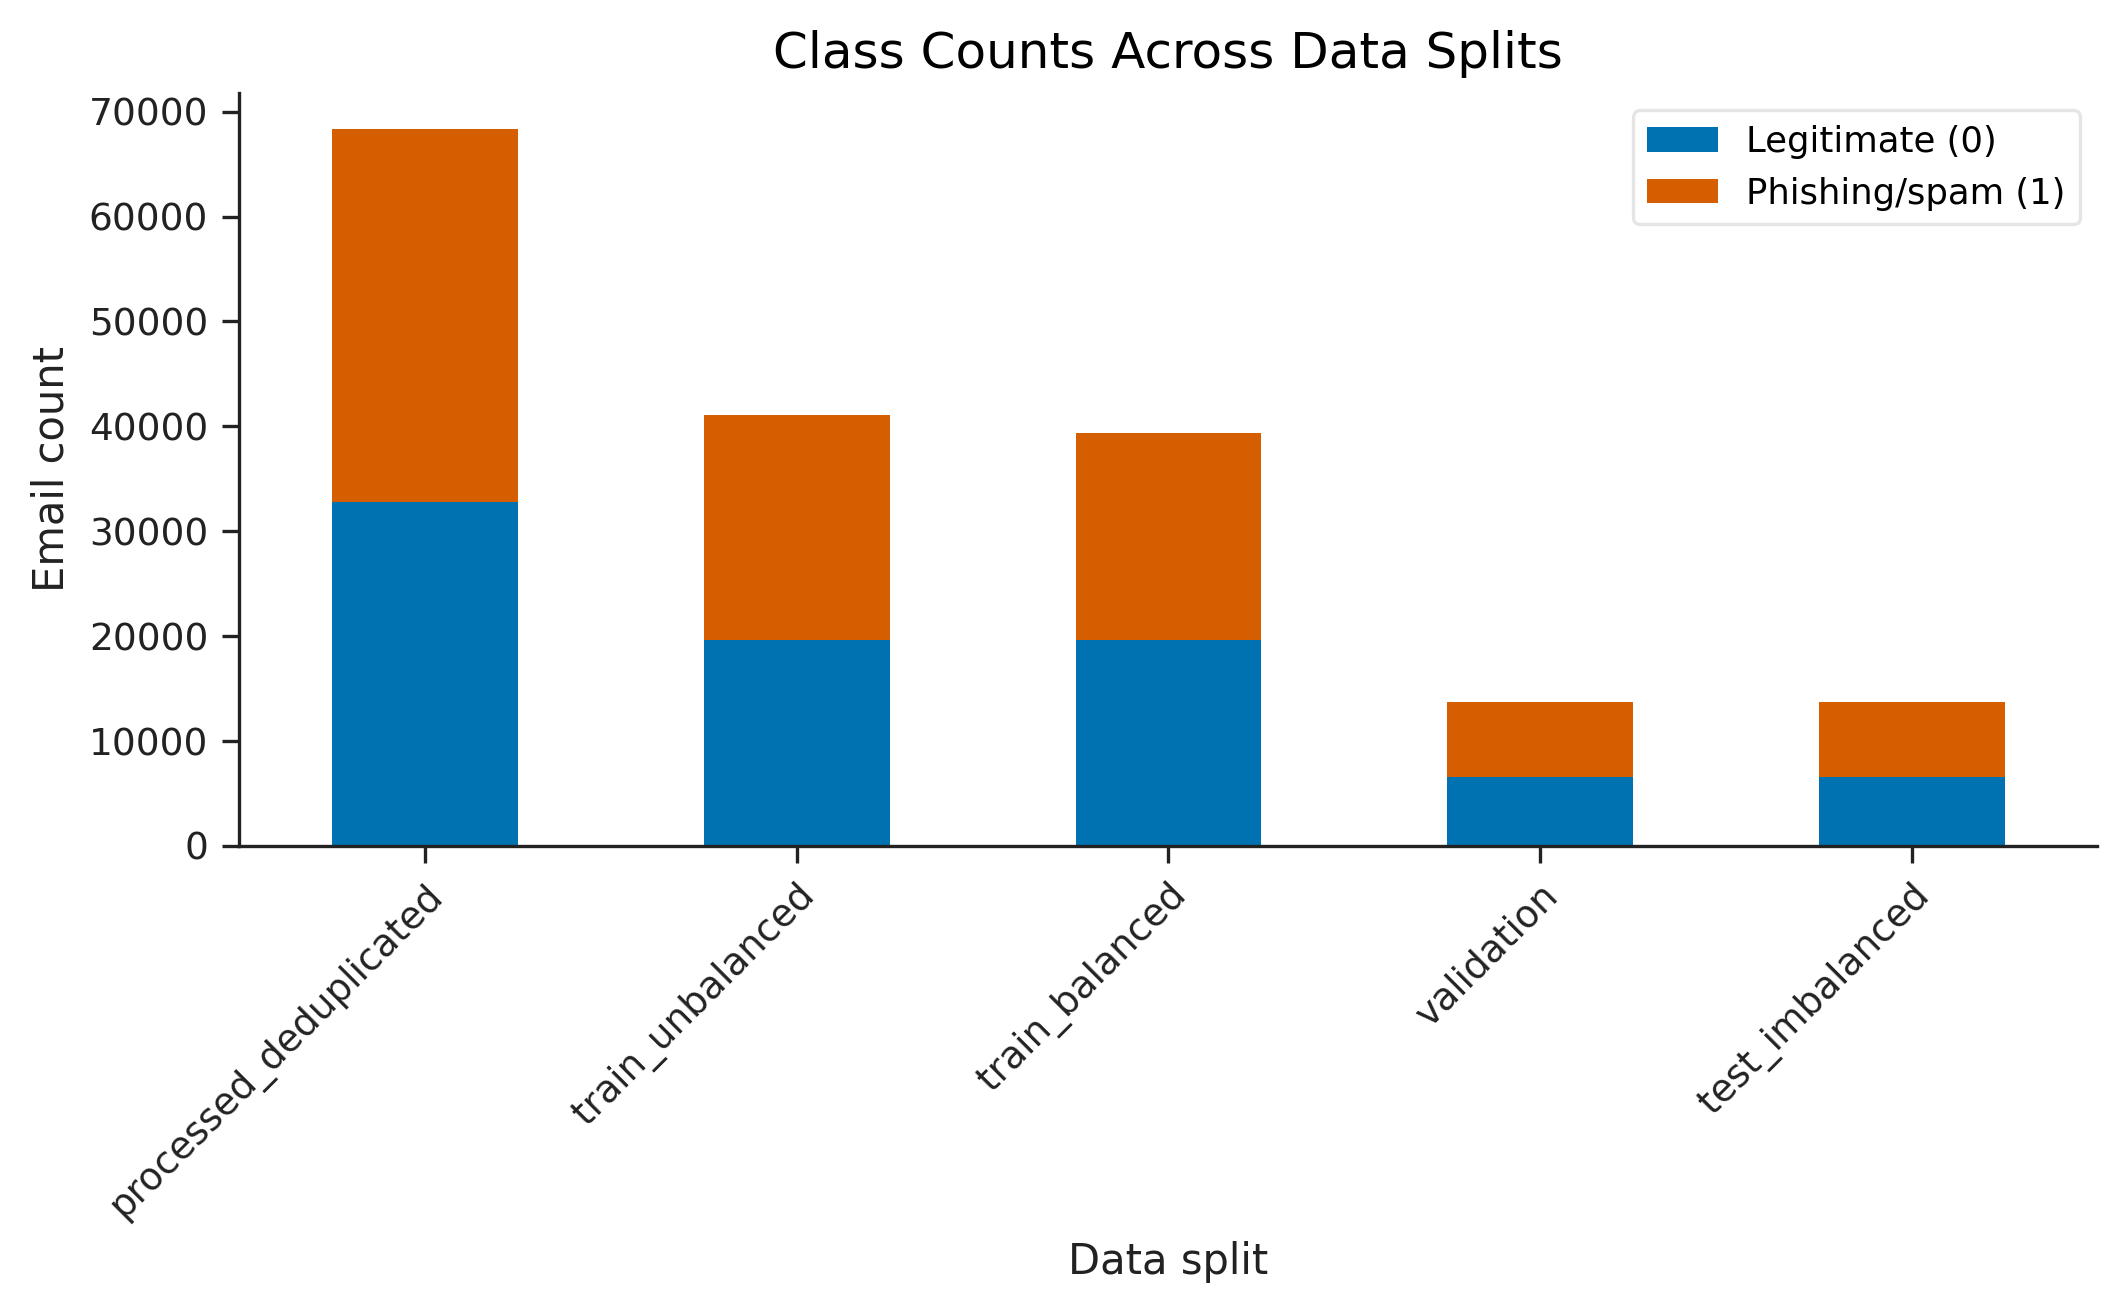

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/preprocessing_rows_removed.png


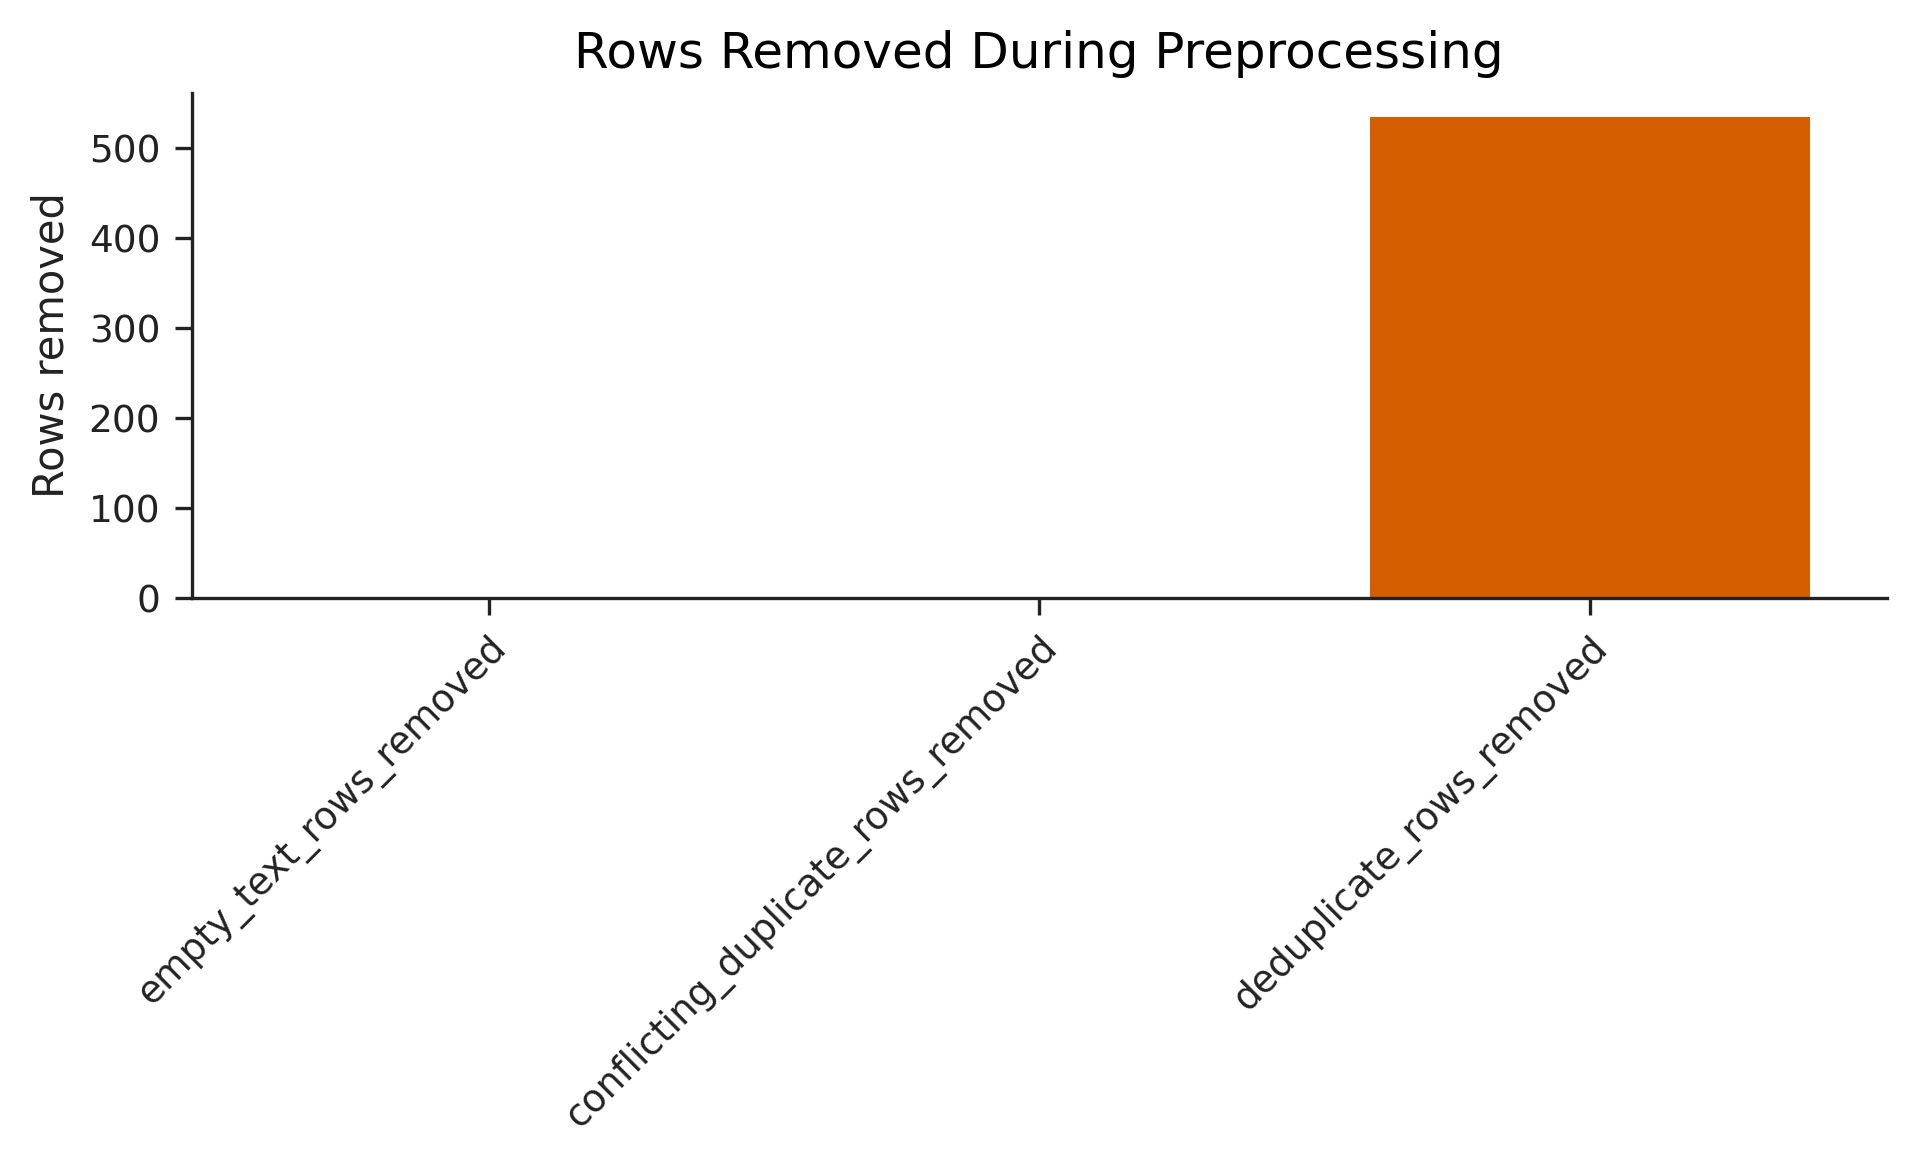

In [2]:
from IPython.display import Image, display


def show_csv_head(path, n=5):
    path = Path(path)
    print(f'CSV preview: {path}')
    if path.exists():
        try:
            display(pd.read_csv(path).head(n))
        except pd.errors.EmptyDataError:
            print('CSV exists but is empty because the optional stage was skipped.')
    else:
        print('Not found yet. Run the earlier cells first.')


def show_png(path):
    path = Path(path)
    print(f'PNG preview: {path}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Not found yet. Run the earlier cells first.')

show_csv_head(DATA_OUTPUT_DIR / 'split_summary.csv')
show_csv_head(DATA_OUTPUT_DIR / 'preprocessing_quality_checks.csv')
show_csv_head(DATA_OUTPUT_DIR / 'processed_deduplicated.csv')
show_png(FIGURE_OUTPUT_DIR / 'split_class_counts.png')
show_png(FIGURE_OUTPUT_DIR / 'preprocessing_rows_removed.png')
